## Can we do a proper Bayesian beam fit with the 16 dipoles?

*like properly this time*

In [1]:
import os
import pickle
from pathlib import Path

import h5py
import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC
from scipy.stats import median_abs_deviation as mad

import pymc as pm
from pymc import Dirichlet, Normal, Deterministic, sample, Model
import pytensor.tensor as pt
import arviz as az

from embers_passes import PassFile

import mwa_hyperbeam
# wget http://ws.mwatelescope.org/static/mwa_full_embedded_element_pattern.h5
os.environ["MWA_BEAM_FILE"] = "../../hyperbeam/mwa_full_embedded_element_pattern.h5"

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

In [2]:
def make_unpol_instrumental_response(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """
    Convert Jones matrices to unpolarized instrumental beam responses.

    Parameters
    ----------
    j1, j2 : np.ndarray
        Arrays of Jones terms with shape (N, 4), where the Jones matrix is
        flattened as [j00, j01, j10, j11].

    Returns
    -------
    np.ndarray
        Array of shape (N, 4) containing [XX, XY, YX, YY] instrumental
        responses for an unpolarized source.
    """
    result = np.empty_like(j1)

    result[:, 0] = j1[:, 0] * j2[:, 0].conjugate() + j1[:, 1] * j2[:, 1].conjugate()
    result[:, 1] = j1[:, 0] * j2[:, 2].conjugate() + j1[:, 1] * j2[:, 3].conjugate()
    result[:, 2] = j1[:, 2] * j2[:, 0].conjugate() + j1[:, 3] * j2[:, 1].conjugate()
    result[:, 3] = j1[:, 2] * j2[:, 2].conjugate() + j1[:, 3] * j2[:, 3].conjugate()

    return result

In [3]:
def hyperbeam_healpix(
    beam,
    nside: int = 32,
    freq_hz: float = 137e6,
    delays =  np.zeros(16, dtype=int),
    amps = np.ones(16),
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """Evaluate the MWA Hyperbeam model on an above-horizon HEALPix grid.
    The beam is evaluated for all HEALPix pixels with zenith angle
    0 <= ZA <= pi/2, corresponding to the upper hemisphere. For a HEALPix
    map with npix = 12 * nside**2 pixels, this includes npix // 2 pixels.
    
    Parameters
    ----------
    beam
        Initialized mwa_hyperbeam.FEEBeam object.
    nside
        HEALPix NSIDE parameter defining the angular resolution of the grid.
    freq_hz
        Frequency at which to evaluate the beam, in Hz.
    delays
        List of 16 beamformer delays, one per dipole. If None, all
        delays are set to zero.
    amps
        List of 16 dipole amplitudes. If ``None``, all amplitudes are set
        to unity.
    norm_to_zenith
        If True, normalize the beam response to unity at zenith.
    parallactic
        If True, include parallactic-angle rotation.

    Returns
    -------
    beam_db
        Array of shape ``(npix // 2, 2)`` containing the unpolarized beam
        response in dB for all above-horizon pixels. Column 0 contains the
        XX polarization and column 1 contains the YY polarization.

    Notes
    -----
    The beam response is computed from the Jones matrices using
    ``makeUnpolInstrumentalResponse`` and converted to decibels via
    ``10 * log10(power)``.
    Any pixels with non-positive power will yield ``-inf``.
    """
    # if delays is None:
    #     delays = [0] * 16

    # if amps is None:
    #     amps = [1.0] * 16

    # if len(delays) != 16:
    #     raise ValueError(f"Expected 16 delays, got {len(delays)}.")

    # if len(amps) != 16:
    #     raise ValueError(f"Expected 16 amplitudes, got {len(amps)}.")

    npix = hp.nside2npix(nside)
    above_horizon = np.arange(npix // 2)

    za, az = hp.pix2ang(nside, above_horizon)

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    beam_xx = np.real(unpol_beam[:, 0])
    beam_yy = np.real(unpol_beam[:, 3])

    beam_db_xx = 10.0 * np.log10(beam_xx)
    beam_db_yy = 10.0 * np.log10(beam_yy)

    return np.column_stack([beam_db_xx, beam_db_yy])

In [4]:
def passes_to_healpix(
    passes,
    nside: int = 32,
    nest: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Bin pass samples onto a HEALPix map.

    Parameters
    ----------
    passes
        Iterable of pass records. Each record must have ``alt_deg``,
        ``az_deg``, and ``power_db`` attributes.
    nside
        HEALPix NSIDE parameter. Default is 32.
    nest
        Use nested ordering if ``True``. Default is ``False``, corresponding
        to ring ordering.

    Returns
    -------
    hp_map
        HEALPix map of mean binned power values. Pixels with no samples are
        NaN.
    counts
        Number of samples contributing to each pixel.
    mad_map
        HEALPix map of the median absolute deviation of samples in each pixel.
        Pixels with no samples are NaN.
    """
    npix = hp.nside2npix(nside)

    sums = np.zeros(npix, dtype=float)
    counts = np.zeros(npix, dtype=int)
    values_by_pix: list[list[float]] = [[] for _ in range(npix)]

    for p in passes:
        alt_deg = np.asarray(p.alt_deg, dtype=float)
        az_deg = np.asarray(p.az_deg, dtype=float)
        power_db = np.asarray(p.power_db, dtype=float)

        mask = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
        )
        if not np.any(mask):
            continue

        theta = np.radians(90.0 - alt_deg[mask])
        phi = np.radians(az_deg[mask])

        pix = hp.ang2pix(nside, theta, phi, nest=nest)
        vals = power_db[mask]

        np.add.at(sums, pix, vals)
        np.add.at(counts, pix, 1)

        for pix_i, val_i in zip(pix, vals):
            values_by_pix[pix_i].append(val_i)

    hp_map = np.full(npix, np.nan, dtype=float)
    mad_map = np.full(npix, np.nan, dtype=float)

    valid = counts > 0
    hp_map[valid] = sums[valid] / counts[valid]

    for pix_i, values in enumerate(values_by_pix):
        if values:
            mad_map[pix_i] = mad(values, scale="normal")

    return hp_map, counts, mad_map

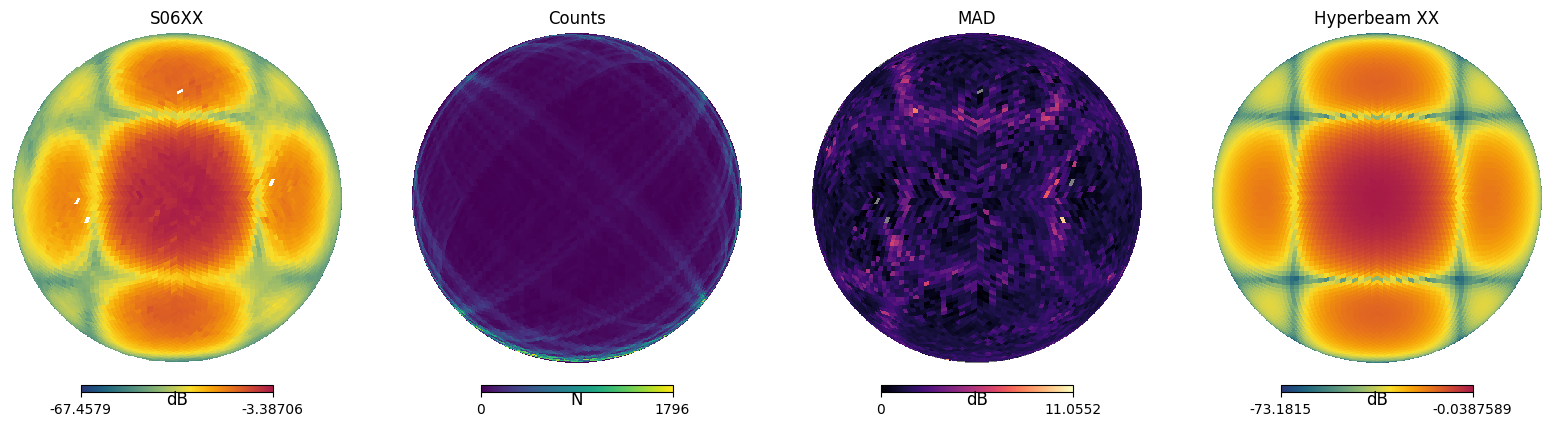

In [5]:
%matplotlib inline

pf = PassFile("../passes/rf0/S06XX_rf0XX_passes.h5")
passes = pf.read_passes(pointing=0)
S06XX_map, count_map, mad_map = passes_to_healpix(passes, nside=32)

# hyperbeam [hb] map
beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])
mwa_map = hyperbeam_healpix(
    beam,
    nside=32,
    freq_hz=137e6,
    amps=np.ones(16),
    # amps=[1.5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
)

hyperbeam_map = np.full(hp.nside2npix(32), hp.UNSEEN, dtype=float)
hyperbeam_map[: mwa_map.shape[0]] = mwa_map[:, 0]


fig = plt.figure(figsize=(16, 4))

maps = [
    S06XX_map,
    count_map,
    mad_map,
    hyperbeam_map,
]

titles = [
    "S06XX",
    "Counts",
    "MAD",
    "Hyperbeam XX",
]

units = [
    "dB",
    "N",
    "dB",
    "dB",
]

cmaps = [
    prd,
    "viridis",
    "magma",
    prd,
]

for i, (m, title, unit, cmap) in enumerate(
    zip(maps, titles, units, cmaps, strict=False),
    start=1,
):
    hp.orthview(
        m,
        rot=(0, 90, 180),
        half_sky=True,
        title=title,
        unit=unit,
        cmap=cmap,
        sub=(1, 4, i),
        fig=fig.number,
        cbar=True,
    )

plt.show()

### Bayesian black magic

In [6]:
## Restrict to above horizon pix
npix = hp.nside2npix(32)
above_horizon = np.arange(npix // 2)

data_db = S06XX_map[above_horizon]
sigma_db = mad_map[above_horizon]

In [7]:
# Mask bad pix
valid_mask = (np.isfinite(data_db) & np.isfinite(sigma_db) & (sigma_db > 0))

data_db = np.asarray(data_db[valid_mask])
sigma_db = np.asarray(sigma_db[valid_mask])
valid_mask = np.asarray(valid_mask)

In [8]:
class HyperbeamLogLike(pt.Op):
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, beam_file, data_db, sigma_db, valid_mask):
        self.beam_file = beam_file
        self.data_db = np.asarray(data_db, dtype=float)
        self.sigma_db = np.asarray(sigma_db, dtype=float)
        self.valid_mask = np.asarray(valid_mask, dtype=bool)
        self._beam = None

    def perform(self, node, inputs, outputs):
        if self._beam is None:
            self._beam = mwa_hyperbeam.FEEBeam(self.beam_file)

        (theta,) = inputs

        model_db = hyperbeam_healpix(
            self._beam,
            nside=32,
            freq_hz=137e6,
            amps=theta,
        )[:, 0]

        model_db = model_db[self.valid_mask]
        resid = self.data_db - model_db

        loglike = -0.5 * np.sum(
            (resid / self.sigma_db) ** 2
            + np.log(2.0 * np.pi * self.sigma_db**2)
        )

        outputs[0][0] = np.asarray(loglike, dtype=float)

In [9]:
loglike_op = HyperbeamLogLike(
    beam_file=os.environ["MWA_BEAM_FILE"],
    data_db=data_db,
    sigma_db=sigma_db,
    valid_mask=valid_mask,
)

with pm.Model() as model:
    p = pm.Dirichlet("p", a=np.ones(16))
    theta = pm.Deterministic("theta", 16.0 * p)

    pm.Potential("beam_likelihood", loglike_op(theta))

    idata = pm.sample(
        draws=3000,
        tune=1000,
        step=pm.DEMetropolisZ(),
        chains=4,
        cores=1,
    )

/Users/achokshi/Repos/embers-passes/.venv/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run HyperbeamLogLike's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sequential sampling (4 chains in 1 job)
DEMetropolisZ: [p]


Output()

/Users/achokshi/Repos/embers-passes/.venv/lib/python3.13/site-packages/pymc/step_methods/metropolis.py:1202: 
RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 256 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


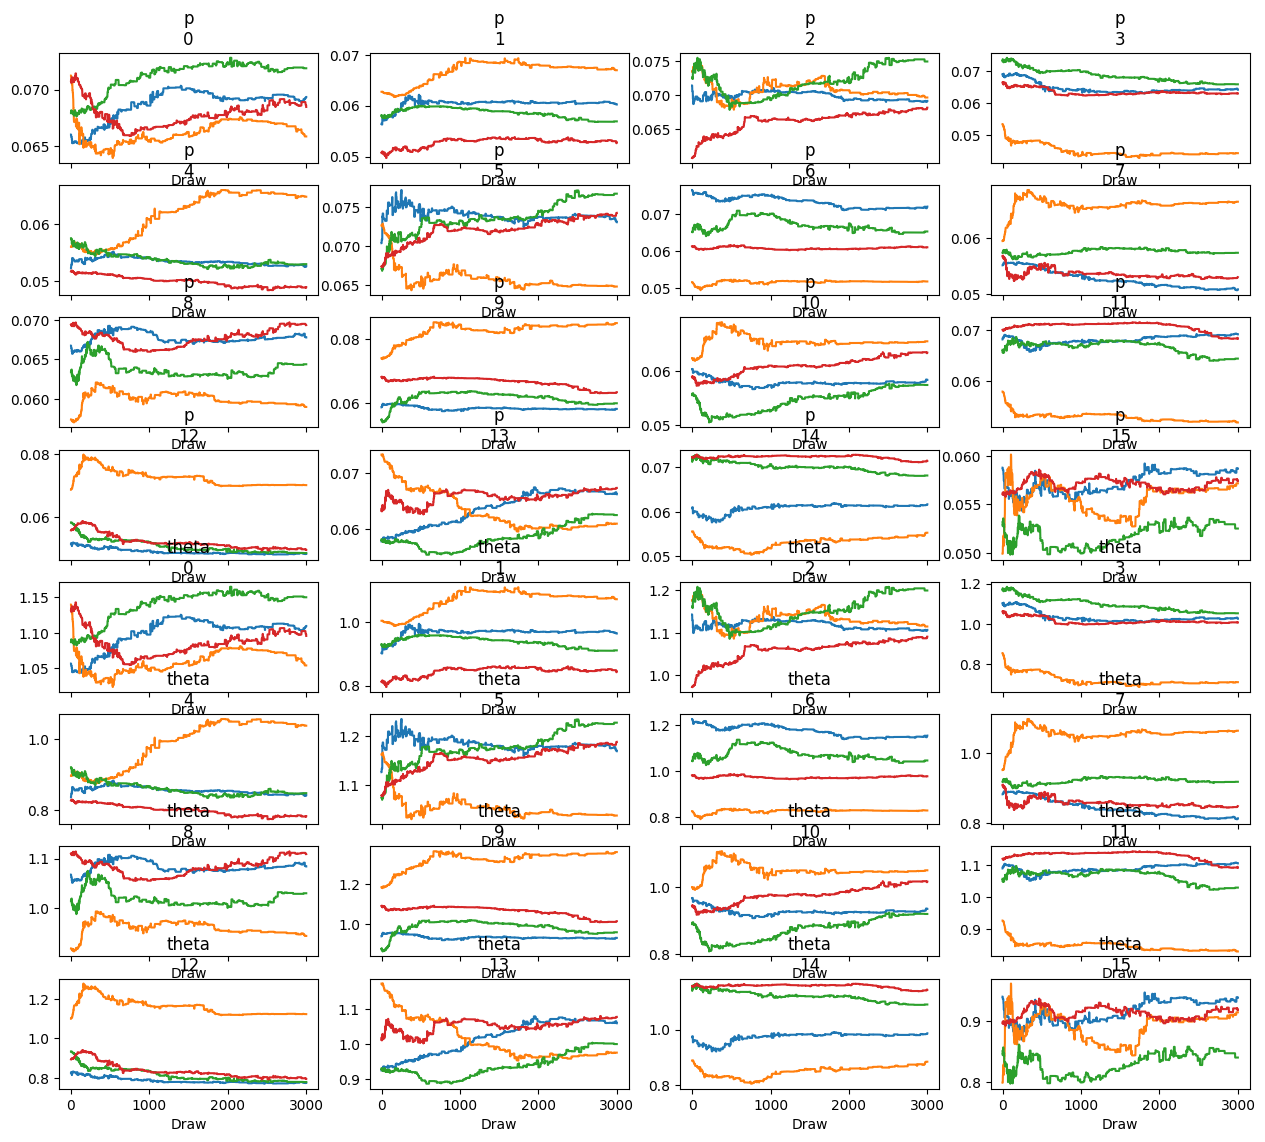

In [10]:
az.plot_trace(idata)

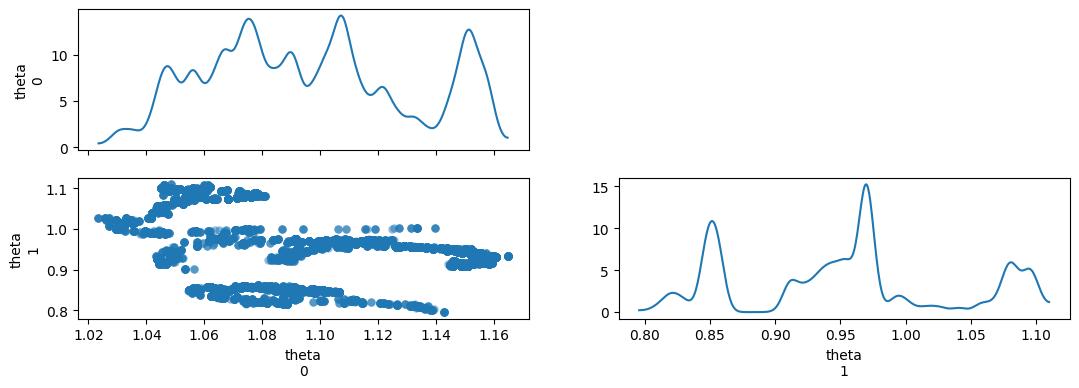

In [12]:
az.plot_pair(
    idata,
    var_names=["theta"],
    coords={"theta_dim_0": [0, 1]},
)